In [ ]:
# Step 1: Import the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# ------------------------------------------------------------------------------------

# Step 2: Load the data from the Excel file
file_name = 'Student Learning Experience Survey (Responses).xlsx'
df = pd.read_excel(file_name)


In [ ]:
# Step 3: Clean the data
# Rename ALL column names to shorter, easier-to-use names
df.rename(columns={
    '1- Which age group do you belong to?': 'Age_Group',
    '2- To which division of computer science do you belong ?': 'Division',
    '3- What is your current year of study?': 'Year',
    '4- Which mode do you prefer for most of your courses?': 'Mode',
    '5- Roughly, how much time per week do you spend on academic activities (lectures, studying, assignments)?': 'Time_Spent_Weekly',
    '6-Have you used YouTube for academic purposes (e.g., watching tutorials, explanations) in the past month?': 'Used_YouTube',
    '7- On average, how many minutes per day do you spend on Blackboard?': 'Blackboard_Time_Daily',
    '8- Do you typically attend optional review sessions or tutorials?': 'Attend_Optional_Sessions',
    '9- How would you rate the effectiveness of your primary learning mode (chosen in Q4) on a scale of 1 to 5? (1 = Very Ineffective, 5 = Very Effective)': 'Effectiveness_Rating',
    '10- On a scale of 0 to 10, how satisfied are you with your overall learning experience this academic year? (0 = Not at all satisfied, 10 = Extremely satisfied)': 'Satisfaction_Rating'
}, inplace=True)

# Standardize the text in the 'Mode' column
df['Mode'] = df['Mode'].apply(lambda x: 'In-person' if 'In-person' in x else ('Hybrid' if 'Hybrid' in x else 'Online'))

# Consolidate the 'More than 4' category into '4th Year'
df['Year'] = df['Year'].replace({'More than 4': '4th Year'})


In [ ]:
# Step 4: Calculate and display descriptive statistics
print("--- 2. Descriptive Statistics ---")

# Table for 'Year of Study' distribution
year_counts = df['Year'].value_counts()
print("Distribution of Students by Year of Study:")
print(year_counts)
print("-" * 40)

# Table for 'Preferred Learning Mode' distribution
mode_counts = df['Mode'].value_counts()
print("\nDistribution of Students by Preferred Learning Mode:")
print(mode_counts)
print("-" * 40)

# Calculate Mean and Median for 'Satisfaction_Rating'
mean_satisfaction = df['Satisfaction_Rating'].mean()
median_satisfaction = df['Satisfaction_Rating'].median()
print(f"\nMean Satisfaction Rating: {mean_satisfaction:.2f} out of 10")
print(f"Median Satisfaction Rating: {median_satisfaction} out of 10")

--- 2. Descriptive Statistics ---
Distribution of Students by Year of Study:
Year
3rd Year    36
2nd Year     8
4th Year     6
1st Year     3
Name: count, dtype: int64
----------------------------------------

Distribution of Students by Preferred Learning Mode:
Mode
Hybrid       26
In-person    23
Online        4
Name: count, dtype: int64
----------------------------------------

Mean Satisfaction Rating: 6.74 out of 10
Median Satisfaction Rating: 7.0 out of 10


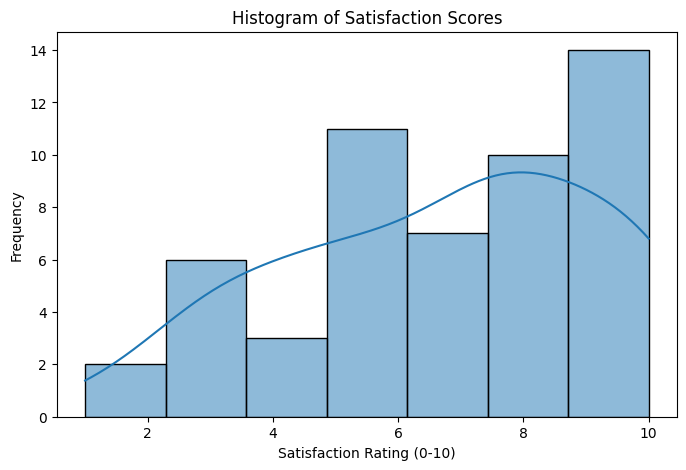

In [ ]:
# --- A. Normality Test for 'Satisfaction_Rating' ---
satisfaction_data = df['Satisfaction_Rating']

# Plot 1: Histogram
plt.figure(figsize=(8, 5))
sns.histplot(satisfaction_data, kde=True)
plt.title('Histogram of Satisfaction Scores')
plt.xlabel('Satisfaction Rating (0-10)')
plt.ylabel('Frequency')
plt.show()

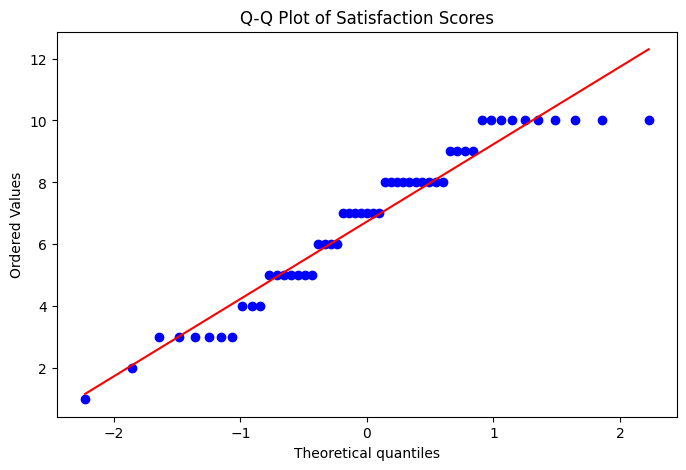

In [ ]:
# Plot 2: Q-Q Plot
plt.figure(figsize=(8, 5))
stats.probplot(satisfaction_data, dist="norm", plot=plt)
plt.title('Q-Q Plot of Satisfaction Scores')
plt.show()

In [ ]:
# Statistical Test: Shapiro-Wilk
stat, p_value = stats.shapiro(satisfaction_data)
print(f"Shapiro-Wilk Test Results:")
print(f"P-value: {p_value:.3f}")
if p_value > 0.05:
    print("Conclusion: The data appears to be normally distributed (fail to reject H0).")
else:
    print("Conclusion: The data does not appear to be normally distributed (reject H0).")


Shapiro-Wilk Test Results:
P-value: 0.004
Conclusion: The data does not appear to be normally distributed (reject H0).


In [ ]:
# --- B. Chi-Square Test of Independence ---
print("--- 4. Chi-Square Test (Year of Study vs. Preferred Mode) ---")

# Create a contingency table (cross-tabulation)
contingency_table = pd.crosstab(df['Year'], df['Mode'])
print("Contingency Table (Observed Frequencies):")
print(contingency_table)
print("-" * 40)

# Perform the Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test Results:")
print(f"P-value: {p:.3f}")

if p < 0.05:
    print("Conclusion: There is a statistically significant association between Year of Study and Preferred Mode (reject H0).")
else:
    print("Conclusion: There is no statistically significant association between Year of Study and Preferred Mode (fail to reject H0).")


--- 4. Chi-Square Test (Year of Study vs. Preferred Mode) ---
Contingency Table (Observed Frequencies):
Mode      Hybrid  In-person  Online
Year                               
1st Year       1          1       1
2nd Year       3          4       1
3rd Year      20         15       1
4th Year       2          3       1
----------------------------------------

Chi-Square Test Results:
P-value: 0.438
Conclusion: There is no statistically significant association between Year of Study and Preferred Mode (fail to reject H0).


In [ ]:
# Perform the Chi-Square test
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-Square Test Results:")
print(f"P-value: {p:.3f}")

if p < 0.05:
    print("Conclusion: There is a statistically significant association between Year of Study and Preferred Mode (reject H0).")
else:
    print("Conclusion: There is no statistically significant association between Year of Study and Preferred Mode (fail to reject H0).")



Chi-Square Test Results:
P-value: 0.438
Conclusion: There is no statistically significant association between Year of Study and Preferred Mode (fail to reject H0).


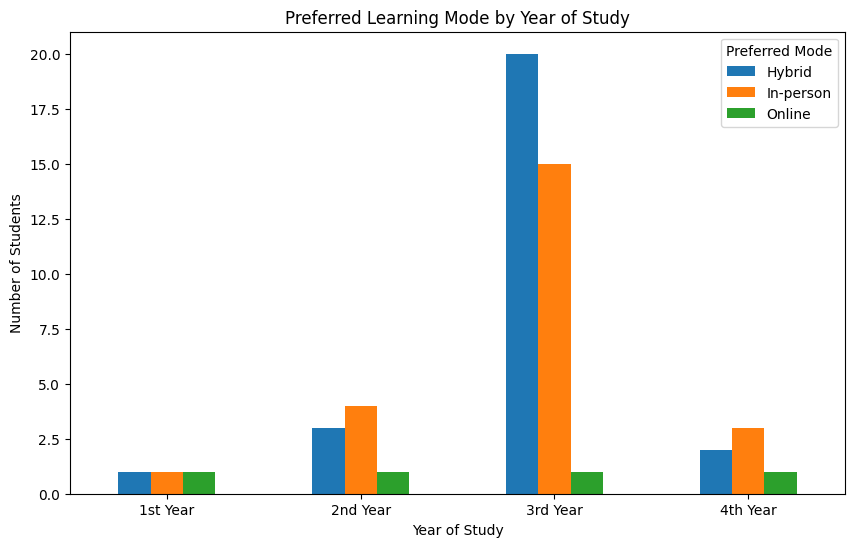

In [ ]:
# Plot 3: Bar chart to visualize the relationship
contingency_table.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Preferred Learning Mode by Year of Study')
plt.xlabel('Year of Study')
plt.ylabel('Number of Students')
plt.legend(title='Preferred Mode')
plt.show()